c:\Users\Mary_Rosy\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:47:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


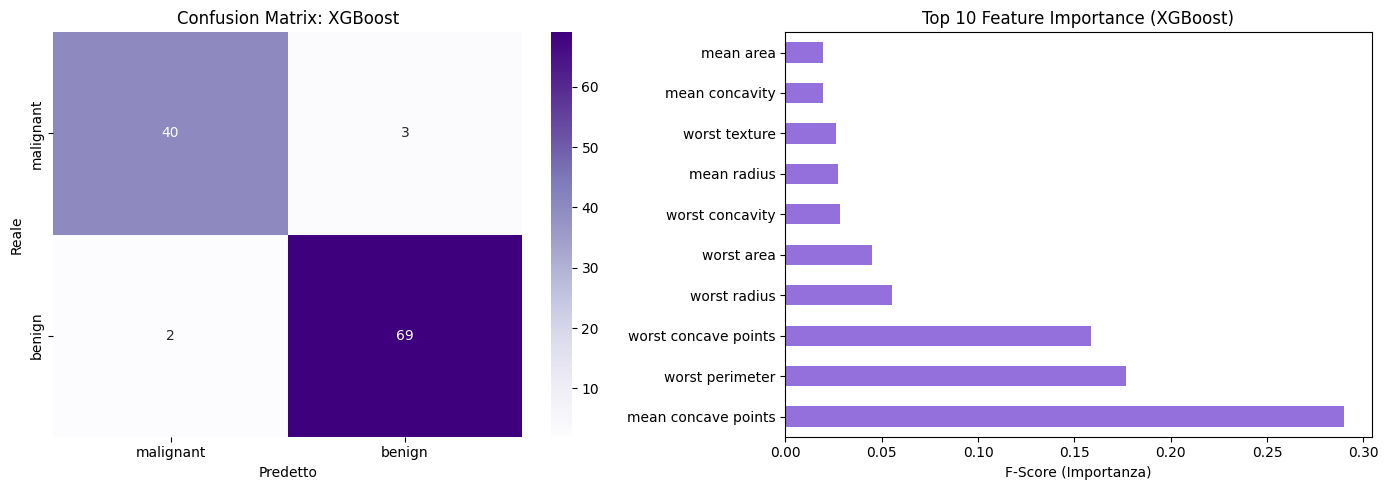

Accuratezza XGBoost: 95.61%

Report Tecnico:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# È necessario installare xgboost: !pip install xgboost
from xgboost import XGBClassifier

# 1. Preparazione dei dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurazione del modello XGBoost
# I parametri chiave:
# n_estimators: numero di alberi sequenziali
# learning_rate (eta): quanto pesano le correzioni di ogni nuovo albero (previene overfitting)
# max_depth: profondità di ogni albero
# gamma: parametro di regolarizzazione (minima riduzione della perdita per fare uno split)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss', # Evita i warning e specifica la funzione di costo
    random_state=42
)

# 3. Addestramento
xgb_model.fit(X_train, y_train)

# 4. Predizione
y_pred = xgb_model.predict(X_test)

# --- VISUALIZZAZIONE RISULTATI ---
plt.figure(figsize=(14, 5))

# Grafico 1: Matrice di Confusione
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# Grafico 2: Feature Importance di XGBoost
plt.subplot(1, 2, 2)
# XGBoost ha un suo metodo per calcolare l'importanza delle feature
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('F-Score (Importanza)')

plt.tight_layout()
plt.show()

# Metriche finali
print(f"Accuratezza XGBoost: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Inizio esperimento... Attendi che l'asterisco [*] diventi un numero.
Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- PARAMETRI OTTIMALI TROVATI ---
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}


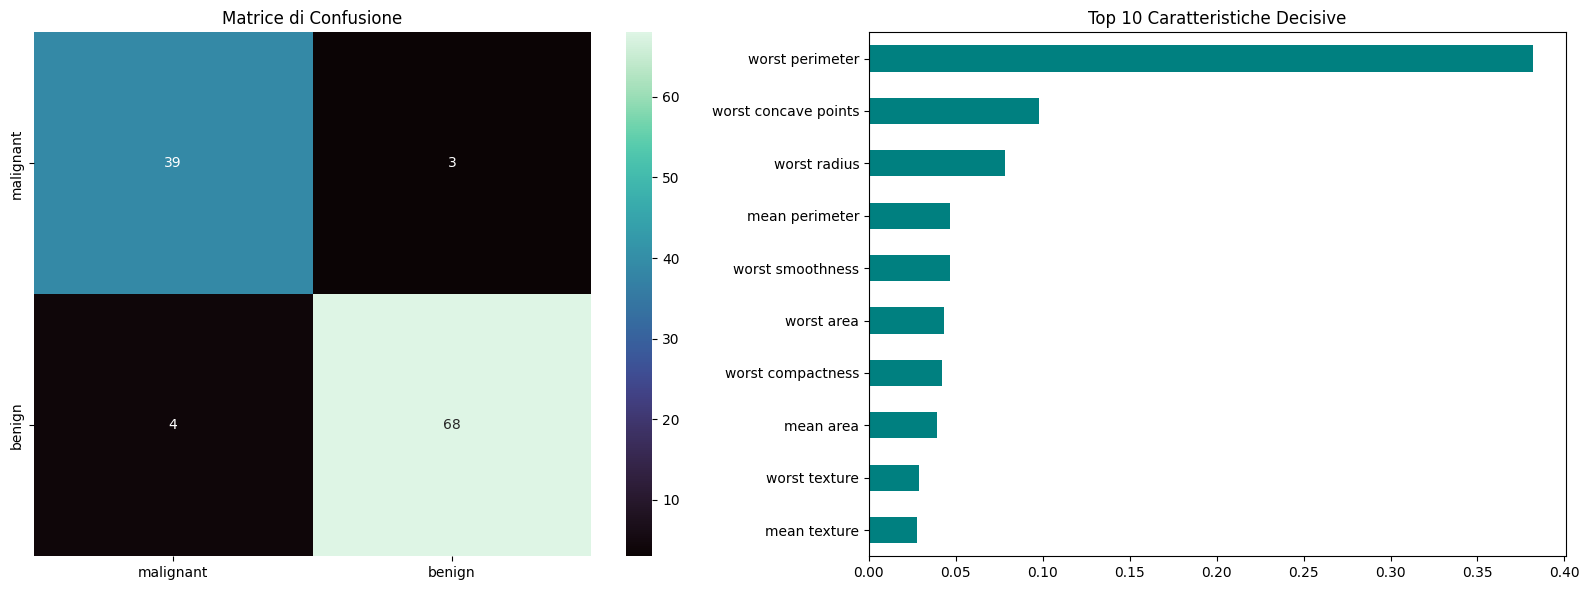


Accuratezza finale: 93.86%


In [6]:
# Aggiungi questa riga all'inizio per essere sicura che Jupyter mostri i grafici
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from xgboost import XGBClassifier

# 1. CARICAMENTO DATI
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# 2. RICERCA PARAMETRI (Grid Search)
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(eval_metric='logloss', early_stopping_rounds=10, random_state=42)

# verbose=1 ci farà vedere i progressi
grid_search = GridSearchCV(xgb_base, param_grid, cv=3, scoring='accuracy', verbose=1)

print("Inizio esperimento... Attendi che l'asterisco [*] diventi un numero.")
grid_search.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

best_model = grid_search.best_estimator_
print("\n--- PARAMETRI OTTIMALI TROVATI ---")
print(grid_search.best_params_)

# 3. PREDIZIONE
y_pred = best_model.predict(X_test)

# 4. GRAFICI
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matrice di Confusione')

plt.subplot(1, 2, 2)
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Caratteristiche Decisive')

plt.tight_layout()
plt.show() # Questo comando "stampa" i grafici a video

# 5. RISULTATI TESTUALI
print(f"\nAccuratezza finale: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Text(145.72222222222223, 0.5, 'Reale')

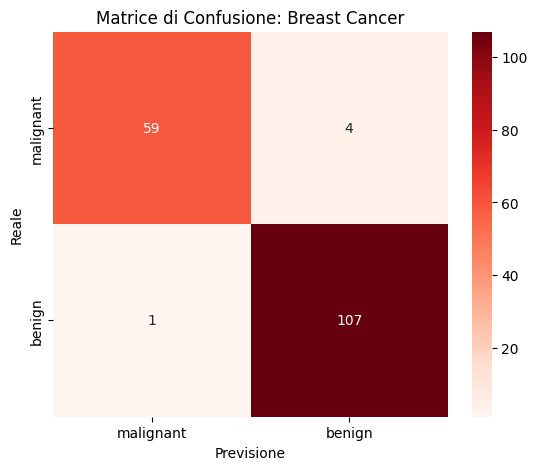

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Caricamento dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Addestramento Random Forest
# Usiamo 100 alberi (n_estimators)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Predizione
y_pred = rf_clf.predict(X_test)

# --- GRAFICO 1: MATRICE DI CONFUSIONE ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matrice di Confusione: Breast Cancer')
plt.xlabel('Previsione')
plt.ylabel('Reale')

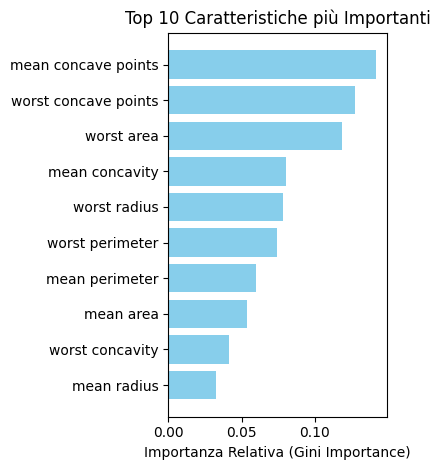

              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        63
      benign       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



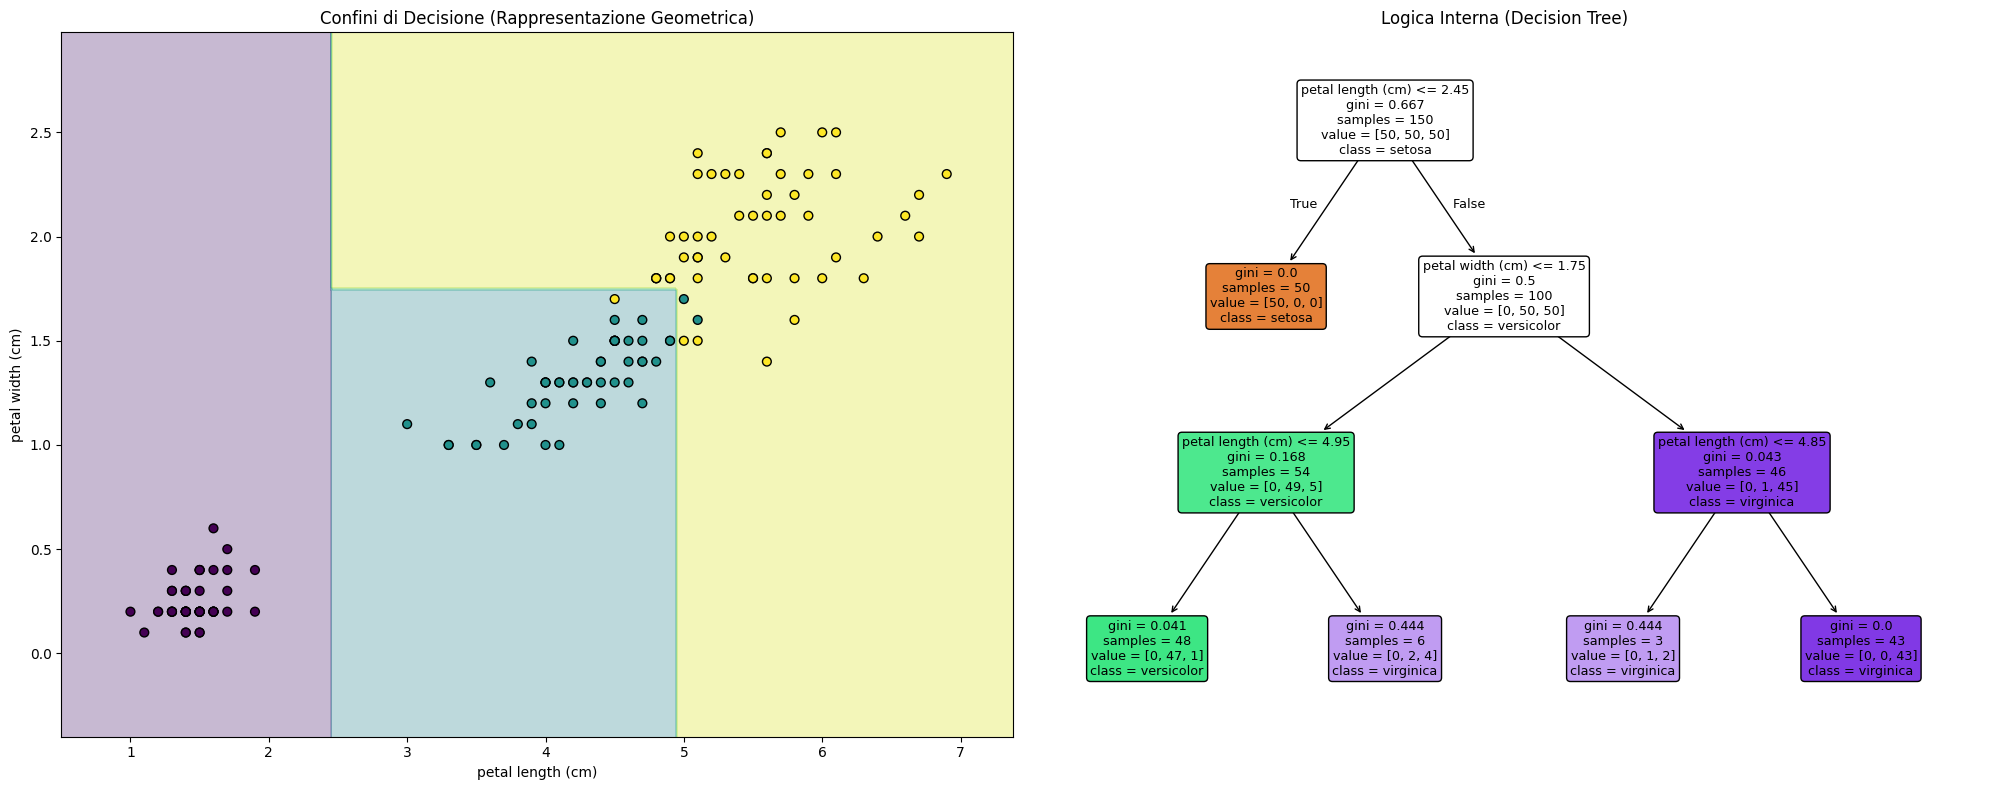

In [8]:
# --- GRAFICO 2: FEATURE IMPORTANCE ---
plt.subplot(1, 2, 2)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-10:] # Prendiamo le 10 più importanti

plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.title('Top 10 Caratteristiche più Importanti')
plt.xlabel('Importanza Relativa (Gini Importance)')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=data.target_names))
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Caricamento dati - Usiamo solo Petal Length e Petal Width per la visualizzazione
iris = datasets.load_iris()
X = iris.data[:, 2:4] # Feature 2 e 3 (Petali)
y = iris.target

# 2. Addestramento del modello
# max_depth=3 è perfetto per vedere bene i "tagli" senza complicare troppo
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X, y)

# 3. Creazione del grafico con due sotto-grafici (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- SOTTO-GRAFICO 1: Confini di Decisione ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap='viridis')
ax1.set_title("Confini di Decisione (Rappresentazione Geometrica)")
ax1.set_xlabel(iris.feature_names[2])
ax1.set_ylabel(iris.feature_names[3])

# --- SOTTO-GRAFICO 2: Struttura dell'Albero ---
plot_tree(tree_clf, 
          feature_names=[iris.feature_names[2], iris.feature_names[3]],  
          class_names=iris.target_names, 
          filled=True, rounded=True, ax=ax2)
ax2.set_title("Logica Interna (Decision Tree)")

plt.tight_layout()
plt.show()